# R-KV Token Dropping with the LMCache SDK
---

Long prompts create large KV caches. They eat GPU memory, limit how many requests
fit in a batch, and a smaller batch means lower decode throughput. *Token
dropping* shrinks each request's KV cache — by half in this notebook — so more
requests fit and decoding runs faster.

This notebook uses the LMCache SDK to pull a request's KV cache out after
prefill, compress it, and put it back before decode. The compression algorithm
is **R-KV**.

## R-KV vs. SnapKV, and why it needs optimizing

SnapKV ranks past tokens by **attention importance** alone: how much the last
`w` prompt tokens attend to them. R-KV keeps that term but subtracts a second
one, **redundancy** — how similar a token's key is to the *other* keys:

$$\text{score}(j) \;=\; \lambda \cdot \underbrace{\text{importance}(j)}_{\text{attended to?}} \;-\; (1-\lambda) \cdot \underbrace{\text{redundancy}(j)}_{\text{says something new?}}$$

Keeping tokens that are both attended-to **and** non-redundant works especially
well on the repetitive output of reasoning models.

The catch is arithmetic. Per layer, for a prompt of $n$ tokens with head
dimension $d$:

| term | cost |
|---|---|
| SnapKV importance (window $w = 64$) | $O(w \cdot n \cdot d)$ |
| R-KV redundancy (**all pairs of keys**) | $O(n^2 \cdot d)$ |

The ratio is $n / w$. At $n = 16128$ that is **~250× more arithmetic per layer
than SnapKV**, and a literal implementation also materializes an $n \times n$
matrix per layer. A direct port of the reference code needed **over an hour** for
the 30 prompts below. Making R-KV practical is what the rest of this notebook is
about.

## What this notebook implements

It implements R-KV **the way the paper describes it** — the literal all-pairs
formulation — made survivable by tiling the $n \times n$ matrix and capping how
many requests touch the GPU at once. It is still $O(n^2 d)$, so it needs ~10 GiB
of VRAM, but it is the version to read first and the one the optimized variants
are checked against.

Three optimized alternatives live in [`rkv_variants/`](./rkv_variants), each a
standalone notebook that can be run on its own:

| | this notebook | [`cpu_exact`](./rkv_variants/rkv_variant_cpu_exact.ipynb) | [`gpu_exact`](./rkv_variants/rkv_variant_gpu_exact.ipynb) | [`buffered_cpu`](./rkv_variants/rkv_variant_buffered_cpu.ipynb) |
|---|---|---|---|---|
| Formulation | route A, literal | route A, linear | route A, linear | route B, chunked |
| Exact? | yes (the reference) | yes, rel. err ~2e-6 | yes, rel. err ~5e-7 | **no**, ~96% agreement |
| Redundancy cost | $O(n^2 d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ |
| VRAM | ~9.8 GiB | none | **1.55 GiB** | none |
| Compress 30 requests | 41.6 s | 67.3 s | **37.5 s** | **29.9 s** |
| Decode throughput | 1766 tok/s | 1785 tok/s | 1774 tok/s | 1774 tok/s |
| Accuracy (baseline 10–11/30) | 16/30 | 15/30 | 16/30 | 14/30 |
| Pick it when | you want the reference formulation | the GPU is saturated by serving | **default choice** | latency beats exactness |

All four keep the same 50% of the tokens, so they deliver the **same decode
speed-up** — 1766–1785 tok/s, a 1.1% spread, even though they
compress with completely different code. What separates them is the **cost of compressing**.

Requirements:

* A small ~10-line modification to vLLM exposes intermediate tensors to LMCache.
  See [README.md](./README.md).
* A GPU is required for serving. To see token dropping increase the decode batch
  size, tune the GPU memory utilization together with the number of requests.
* Data moves between the LMCache server and the SDK through shared memory; if it
  is unavailable the SDK falls back to pickle.


## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 400 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query \
    --supported-transfer-mode auto
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
LMCACHE_TRANSFER_INTERMEDIATE_TENSORS=true \
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import (
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-08-12 00:25:00,721] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/sigma/github/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)
[2026-08-12 00:25:00,804] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.4.dev21 (g0c487832)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [2]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

# Streams prefilled per submission. LMCache's query ring buffer maps a forward
# step's query rows to ring slots positionally (qringbuffer.py
# build_q_step_state), assuming each request contributed exactly its store op's
# token count of rows. Continuous batching breaks that, so the captured queries
# are silently wrong or short. Measured query-row reproducibility across two
# identical runs: 100.0% at 1 stream, 99.7% at 4, 9.8% at 30. R-KV's importance
# term is entirely query-driven, so prefill is submitted one stream at a time.
prefill_group_size = 1

## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-08-12 00:25:26,633] LMCache INFO: Initialized LMCacheSDKContext with instance_id=1417601518969451735, model_name=/data/models/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:122:lmcache.sdk.context)
[2026-08-12 00:25:26,636] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-12 00:25:26,833] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-12 00:25:26,840] LMCache INFO: Engine KV Format: 7 NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)
[2026-08-12 00:25:26,842] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=268435456000) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-08-12 00:25:26,955] LMCache INFO: Cud

## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 423428 tokens.
Mean prompt length: 14114.27 tokens.
Max prompt length: 16807 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)


In [5]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:27:52,708] LMCache INFO: prefill: 2.72 s in groups of 1 (420791162.py:24:__main__)


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       170.75
Total Output Tokens:                                                      153484
Decode Throughput (tokens/s):                                             898.88


## Clear LMCache


In [6]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

## With R-KV Token Dropping

Three implementations follow, all producing the same R-KV scores and differing
only in *how* the redundancy term is evaluated and *where* it runs. This cell
holds the hyperparameters and the tensor plumbing they share.


In [7]:
# Standard
import contextlib
import threading

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
rkv_window_size = 16  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.25  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = (
        flat.to(dtype=torch.float32)
        if device is None
        else flat.to(device, torch.float32)
    )
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=rkv_sim_threshold):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()

### Route A, one-shot, on the GPU

> **Trades VRAM and scaling for simplicity.** It is R-KV written the way the
> paper describes it, so it is the easiest to read and to check against the
> reference — but it pays $O(n^2)$ in both time and memory.
>
> | | |
> |---|---|
> | **Buys you** | The simplest, most literal code; easy to verify against the reference implementation |
> | **Costs you** | ~9.8 GiB of VRAM, and cost grows **quadratically** with prompt length |
> | Exact? | Yes |
> | VRAM | ~9.8 GiB (concurrency cap 4) |
> | Compress 30 requests | 41.6 s |
> | Decode throughput | 1766 tok/s |
> | Pick it when | You want the reference formulation, prompts are short, and VRAM is plentiful; see [rkv_variants/](./rkv_variants) otherwise |

**Route A** is R-KV as written: every past token is scored against the *whole*
prompt, so the redundancy term is the full $n \times n$ cosine matrix. This
implementation keeps that formulation and simply makes it survivable.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Window-only queries.** The reference builds a full `[kv_heads, n, n]` logit tensor and then throws away everything except the last `w` rows. Slicing the queries *before* the matmul computes only the rows that survive. | $n / w \approx 2000\times$ fewer FLOPs on the importance term, and the host→device copy of Q drops from ~4.8 GiB to ~2.4 MiB per request. |
| 2 | **Tiled column sums.** R-KV reduces the similarity matrix with a mean over rows, so only a per-column accumulator has to survive. Rows are processed `row_block` at a time. The per-row "retain" index is read straight off the boolean mask with `flip(-1).argmax(-1)`. | The reference's `torch.where(mask, arange, 0)` idiom allocates **two int64 `[kv_heads, n, n]` tensors** — 16.6 GiB each at $n=16128$ — on top of the fp32 matrix. Removing them turned a DRAM-bound pass into a compute-bound one. |
| 3 | **Per-layer key staging.** Keys are copied to the device one layer at a time. | Staging all 36 layers up front is a 1.19 GiB *resident* allocation per in-flight request that no tile size can shrink. |
| 4 | **Concurrency cap.** A semaphore bounds how many requests are inside the GPU section at once. | See below — this is the one that decides whether the run survives at all. |

## GPU footprint and how the concurrency cap is derived

The trap is that `batch.modify` submits **one worker thread per stream**
(`ThreadPoolExecutor(max_workers=len(stream_ids))`), so all 30 requests execute
the compression function *simultaneously in one CUDA context*. A single-request
measurement therefore understates the real peak by 30×.

Per-request footprint is estimated from tensor shapes, as the larger of the two
phases (they never overlap inside a thread):

$$
\text{scoring} = \underbrace{n \cdot D \cdot 10}_{\text{staged + fp32 + normalised}} + \underbrace{H \cdot \text{row\_block} \cdot n \cdot 7}_{\text{fp32 tile + masks}}
\qquad
\text{rerotate} = 2 L \cdot \text{keep} \cdot D \cdot 2 \;+\; \text{RoPE temporaries}
$$

At $n = 16807$, keep 50%: scoring 1.06 GiB vs rerotate **1.28 GiB** — the
rerotate gather binds, which is why lowering `row_block` would *not* help here.
Total peak was then fitted against a measured 30-thread sweep and rounded up:

$$\text{peak}(\text{cap}) \approx \text{per\_request} \times (1.4 \cdot \text{cap} + 3.0)$$

| cap | measured peak |
|---|---|
| 2 | 6.47 GiB |
| 4 | 9.80 GiB |
| 8 | 16.25 GiB |

Inverting it gives the cap from the free VRAM reported by
`torch.cuda.mem_get_info` — which is device-wide, so vLLM's pool and the LMCache
server's own CUDA context are already subtracted — minus a reserve for what
grows *after* the snapshot (vLLM activations during decode, allocator
fragmentation). If not even one request fits, scoring falls back to the CPU
instead of crashing.

Wall-clock was flat at 42.9 / 42.2 / 41.5 s for cap 2 / 4 / 8, so the cap costs
no throughput: the slow part of `modify` is waiting on LMCache, which happens
before the gate and stays fully concurrent.

**Result: ~9.8 GiB of VRAM, 41.6 s to compress 30 requests.**


In [8]:
# --- Knobs -------------------------------------------------------------------
oneshot_device = "cuda:0"  # a request only; downgraded to CPU if VRAM is short
oneshot_row_block = 1024  # rows scored per tile
oneshot_vram_reserve_gib = 8.0  # held back for what grows after the snapshot
oneshot_cap_limit = 4  # ceiling on the auto-sized concurrency cap
oneshot_allow_tf32 = True  # kept-token set was bit-identical to strict fp32

# peak(cap) ~= per_request * (GROWTH * cap + BASE), fitted above the measured
# 30-thread sweep (6.47 / 9.80 / 16.25 GiB at cap 2 / 4 / 8) so sizing errs small.
_PEAK_GROWTH, _PEAK_BASE = 1.4, 3.0


def _oneshot_redundancy(key_states, row_block):
    """Route A redundancy, tiled over rows.

    Same values as `redundancy_reference` but peak memory is
    O(kv_heads * row_block * n) instead of O(kv_heads * n^2), and no int64
    temporaries are built.
    """
    bsz, kv_heads, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    col_sum = torch.zeros((bsz, kv_heads, n), dtype=torch.float32, device=k.device)

    for r0 in range(0, n, row_block):
        r1 = min(r0 + row_block, n)
        sim = torch.matmul(k[:, :, r0:r1, :], k.transpose(-1, -2))
        local = torch.arange(r1 - r0, device=k.device)
        sim[:, :, local, r0 + local] = 0.0  # a token is not redundant with itself

        # `similarity_retain`: the largest above-threshold column per row, read
        # as "first True scanning from the right"; column 0 when none qualifies.
        over = sim > rkv_sim_threshold
        hit = over.any(dim=-1)
        last = (n - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
        retain = torch.where(hit, last, torch.zeros_like(last))
        sim.scatter_(-1, retain.unsqueeze(-1), 0.0)

        col_sum += sim.sum(dim=-2)
        del sim, over, hit, last, retain

    return (col_sum / n).softmax(dim=-1)


def _oneshot_estimate(seq_len, num_layers, kv_heads, head_dim, row_block):
    """Per-request device bytes: (peak, scoring, rerotate)."""
    kvd = kv_heads * head_dim
    scoring = seq_len * kvd * 10 + kv_heads * min(row_block, seq_len) * seq_len * 7
    keep = int(round(seq_len * (1 - rkv_drop_ratio)))
    rerotate_b = 2 * num_layers * keep * kvd * 2 + 8 * keep * kvd * 2
    return max(scoring, rerotate_b), scoring, rerotate_b


def _oneshot_plan(spec):
    """Pick the device and size the concurrency cap from free VRAM."""
    dev = torch.device(spec)
    if dev.type != "cuda" or not torch.cuda.is_available():
        logger.info("Route A one-shot: running on the CPU, no cap needed.")
        return torch.device("cpu"), 0

    seq_len = max(len(p) for p in prompts)  # size against the worst case
    _, kv_heads, head_dim = model_heads()
    per_req, scoring, rerotate_b = _oneshot_estimate(
        seq_len, int(config.num_hidden_layers), kv_heads, head_dim, oneshot_row_block
    )
    binding = "scoring tile" if scoring >= rerotate_b else "rerotate gather"

    free_b, total_b = torch.cuda.mem_get_info(dev)
    usable = free_b - int(oneshot_vram_reserve_gib * 2**30)
    cap = int((usable / per_req - _PEAK_BASE) / _PEAK_GROWTH) if usable > 0 else 0
    cap = max(0, min(cap, oneshot_cap_limit))

    logger.info(
        f"Route A one-shot on {dev}: {free_b / 2**30:.1f}/"
        f"{total_b / 2**30:.1f} GiB free, "
        f"reserving {oneshot_vram_reserve_gib:.1f} -> {usable / 2**30:.1f} GiB usable; "
        f"{per_req / 2**30:.2f} GiB per request (bound by the {binding}) -> cap {cap}"
    )
    if cap < 1:
        logger.warning("Not enough VRAM for one request; falling back to the CPU.")
        return torch.device("cpu"), 0
    return dev, cap


_oneshot_dev, _oneshot_cap = _oneshot_plan(oneshot_device)
_oneshot_slot = (
    threading.Semaphore(_oneshot_cap) if _oneshot_cap else contextlib.nullcontext()
)
if _oneshot_dev.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = oneshot_allow_tf32
    torch.backends.cudnn.allow_tf32 = oneshot_allow_tf32


def drop_tokens_oneshot(tensors, token_source):
    """Route A token dropping. Runs on ~30 threads at once, hence the gate."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()
    dev = _oneshot_dev

    with _oneshot_slot:
        q_win = q_win.to(dev, non_blocking=True)
        scores = torch.zeros(past_len, dtype=torch.float32, device=dev)

        for layer in range(kv.shape[1]):
            # One layer of K at a time: 33 MiB instead of 1.19 GiB resident.
            k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim, dev)
            qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim, dev)
            imp = importance(k, qw, past_len)
            red = _oneshot_redundancy(k, oneshot_row_block)[:, :, :past_len]
            layer_score = imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)
            scores += layer_score.mean(dim=1).squeeze(0)
            del k, qw, imp, red, layer_score

        keep_idx = select(scores, past_len, seq_len, keep_past)
        del scores, q_win

        e_kv = rerotate(kv, keep_idx, dev)

    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_oneshot(n=384, layers=3):
    """The tiled redundancy must equal the literal reference."""
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    worst = 0.0
    for _ in range(layers):
        k = torch.randn(1, num_kv, n, head_dim, device=_oneshot_dev)
        ref = redundancy_reference(k)
        got = _oneshot_redundancy(k, row_block=64)  # force multiple tiles
        worst = max(worst, (ref - got).abs().max().item())
    logger.info(f"Route A one-shot self-test: max |reference - tiled| = {worst:.2e}")
    assert worst < 1e-5, f"tiled redundancy diverged ({worst:.2e})"


_selftest_oneshot()

[2026-08-12 00:31:12,284] LMCache INFO: Route A one-shot on cuda:0: 37.3/139.8 GiB free, reserving 8.0 -> 29.3 GiB usable; 1.28 GiB per request (bound by the rerotate gather) -> cap 4 (3054693816.py:72:__main__)
[2026-08-12 00:31:12,517] LMCache INFO: Route A one-shot self-test: max |reference - tiled| = 4.66e-10 (3054693816.py:132:__main__)


In [9]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_oneshot)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
oneshot_drop_data = results.to_dict()
oneshot_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:31:37,998] LMCache INFO: prefill: 15.17 s in groups of 1 (2183302842.py:24:__main__)
[2026-08-12 00:31:43,275] LMCache INFO: compacted 5120/10240 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:43,766] LMCache INFO: compacted 4992/9984 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:44,175] LMCache INFO: compacted 5504/11008 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:44,623] LMCache INFO: compacted 5376/10752 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:46,911] LMCache INFO: compacted 5632/11264 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:47,492] LMCache INFO: compacted 5632/11264 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:47,936] LMCache INFO: compacted 5376/10752 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:48,546] LMCache INFO: compacted 6144/12288 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:51,313] LMCache INFO: compacted 6400/12800 tokens. (3054693816.py:118:__main__)
[2026-08-12 00:31:5

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        41.36
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        86.96
Total Output Tokens:                                                      153389
Decode Throughput (tokens/s):                                            1763.94


## Other implementations

The version above is the literal R-KV formulation: easy to read, easy to check
against the reference, and $O(n^2)$ in both time and memory. Three optimized
alternatives live in [`rkv_variants/`](./rkv_variants). Each is a **standalone
notebook** — same setup, same prompts, same baseline, but a different way of
evaluating the redundancy term:

| Notebook | What it changes | Result |
|---|---|---|
| [`cpu_exact.ipynb`](./rkv_variants/rkv_variant_cpu_exact.ipynb) | Rewrites the column sum R-KV actually needs as a single inner product, so the $n \times n$ matrix never exists. | Same tokens, $O(n d)$ plus a short scan, **no VRAM at all**. |
| [`gpu_exact.ipynb`](./rkv_variants/rkv_variant_gpu_exact.ipynb) | The same rewrite on the GPU, tiled over rows so the footprint is a knob rather than a function of prompt length. | Same tokens, **~1.55 GiB** and the fastest of the four. |
| [`buffered_cpu.ipynb`](./rkv_variants/rkv_variant_buffered_cpu.ipynb) | Compares keys only inside a chunk, making the similarity matrix block-diagonal. | **Approximate** (~96% token agreement), the quickest CPU option. |

| | this notebook | [`cpu_exact`](./rkv_variants/rkv_variant_cpu_exact.ipynb) | [`gpu_exact`](./rkv_variants/rkv_variant_gpu_exact.ipynb) | [`buffered_cpu`](./rkv_variants/rkv_variant_buffered_cpu.ipynb) |
|---|---|---|---|---|
| Formulation | route A, literal | route A, linear | route A, linear | route B, chunked |
| Exact? | yes (the reference) | yes, rel. err ~2e-6 | yes, rel. err ~5e-7 | **no**, ~96% agreement |
| Redundancy cost | $O(n^2 d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ |
| VRAM | ~9.8 GiB | none | **1.55 GiB** | none |
| Compress 30 requests | 41.6 s | 67.3 s | **37.5 s** | **29.9 s** |
| Decode throughput | 1766 tok/s | 1785 tok/s | 1774 tok/s | 1774 tok/s |
| Accuracy (baseline 10–11/30) | 16/30 | 15/30 | 16/30 | 14/30 |
| Pick it when | you want the reference formulation | the GPU is saturated by serving | **default choice** | latency beats exactness |

The two exact variants assert themselves against `redundancy_reference` — the
same oracle used in the cell above — so their notebooks fail loudly if the
rewrite ever stops reproducing R-KV.


### Accuracy


In [10]:
before_correct, total, before_map = score_answers(answers, before_texts)
oneshot_correct, total, oneshot_map = score_answers(answers, oneshot_texts)

logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"R-KV one-shot (GPU): {oneshot_correct}/{total} correct "
    f"({100 * oneshot_correct / total:.1f}%)"
)

[2026-08-12 00:33:56,498] LMCache INFO: Baseline (no drop): 11/30 correct (36.7%) (3159123651.py:4:__main__)
[2026-08-12 00:33:56,499] LMCache INFO: R-KV one-shot (GPU): 16/30 correct (53.3%) (3159123651.py:8:__main__)


## Result Plot


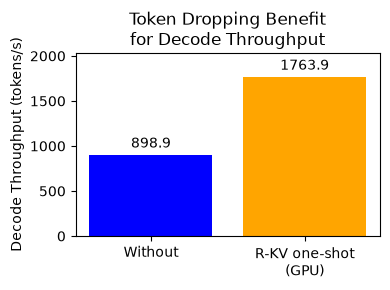

In [11]:
labels = ["Without", "R-KV one-shot\n(GPU)"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    oneshot_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Reading these numbers

All four notebooks were run back to back on one machine against the same vLLM
and LMCache servers, and each re-measures its own no-drop baseline. That gives
four independent measurements of an **identical** configuration — a direct read
on how much of any difference is real:

| | one-shot | gpu_exact | cpu_exact | buffered_cpu |
|---|---|---|---|---|
| baseline decode | 969 tok/s | 1008 tok/s | 1002 tok/s | 975 tok/s |
| baseline accuracy | 11/30 | 11/30 | 10/30 | 10/30 |
| decode after dropping | 1766 tok/s | 1774 tok/s | 1785 tok/s | 1774 tok/s |
| accuracy after dropping | 16/30 | 16/30 | 15/30 | 14/30 |

Three things follow.

1. **Decode throughput after dropping is the solid number.** It lands in
   1766–1785 tok/s — a 1.1% spread — although the four notebooks compress with
   completely different code. That is the claim this example makes: the speed-up
   comes from halving the KV cache, not from how the halving is computed.

2. **Don't quote a speed-up ratio.** The no-drop baseline swung 969–1008 tok/s
   here, and 894–1076 tok/s — **20%** — over an earlier sweep of the same four
   notebooks, so the ratio moves between 1.6x and 2.0x on noise alone. Compare
   the absolute post-drop throughput instead.

3. **Don't rank the variants by accuracy.** R-KV beat the same-run baseline in
   all four runs (+4 to +5 of 30), which is the meaningful result. But the 1/30
   spread *between* variants is the same size as the baseline's own spread, so
   it says nothing about the algorithms.

### Why identical inputs give different text

Decoding is greedy — `temperature = 0.0` for both prefill and decode — yet the
generated text still differs between runs. `temperature = 0` fixes the *rule*
(take the argmax); it does not make the argmax stable.

Prefill is submitted one stream at a time (`prefill_group_size = 1`) and it
**is** reproducible: 15.19 s and 15.21 s, to the same hundredth of a second, in
every notebook. Decode is not. `batch.decode` hands all 30 streams to vLLM at
once, so continuous batching gives the decode batch a different composition on
every run. GPU reductions are not batch-invariant, logits move by ~1e-6,
near-ties flip, and autoregression amplifies the divergence.

This is a property of the serving stack, not of token dropping — but it is the
reason a single accuracy number here should not be read as a ranking.

### The exact variants pick the same tokens — their caches still differ

Verified directly on real requests: `cpu_exact` and `gpu_exact` produce score
vectors that differ by ~1e-6, but the top-k they select was identical on every
request tested, and so were the kept token ids. Their compacted caches are
nevertheless not byte-identical:

| | differing elements | largest difference |
|---|---|---|
| V — a pure gather | **0** | 0 |
| K — goes through the RoPE re-rotation | 0.004% | one to two bfloat16 ULP |

Every difference is in K, and it is the *device*: `cpu_exact` re-rotates on the
CPU, `gpu_exact` on the GPU, and their sin/cos implementations and fused
multiply-adds round differently before the result is stored back as bfloat16.
Feeding one identical tensor to `rerotate_k_cache` on each device reproduces the
same signature exactly, so nothing else is involved.

One ULP in K is enough to move an attention logit, flip a near-tied greedy
argmax, and diverge from there. That is why two implementations which provably
select the same tokens still generate different text, and can land on a
different answer for one or two of the 30 questions.

#### Why the re-rotation runs in fp32

`utils.rerotate_k_cache` detaches one RoPE and attaches another: six multiplies
and two adds per element. Carrying that out in the cache's own bfloat16 rounds
at every step. Measured on keys with a standard deviation of 3:

| arithmetic | keys changed vs fp32 | rotate-away-and-back error | re-rotate 30 requests |
|---|---|---|---|
| bfloat16 | 50% | 2.5e-1 | 3.2 s |
| **fp32** (used here) | — | **6.3e-2** | 6.1 s |

fp32 costs 1.9x on the re-rotation step itself, because it moves twice the
bytes. End to end that is much less than it sounds: compressing the 30 requests
went from 41.4 to 41.6 s (one-shot), 37.3 to 37.5 s (`gpu_exact`) and 67.1 to
67.3 s (`cpu_exact`) — around +0.2 s, because `modify` spends most of its time
waiting on LMCache and the extra arithmetic fits in that slack. Only
`buffered_cpu` shows it, 27.9 to 29.9 s (+7%), because its compression is the
shortest so the re-rotation is the largest share of it. That buys a 4x better
round trip and takes an extra ULP of error off half the keys, so it is the
default. It does **not** remove the CPU/GPU split above: that is
the final rounding back to bfloat16, which is there whatever precision the
rotation is computed in.


## Close both contexts

In [12]:
# Only close the context when done.
ctx.close()
qctx.close()